In [22]:
%load_ext autoreload
%autoreload 2

In [3]:
import sys
sys.path.append('./')
sys.path.append('/Users/ASUS/Documents/GitHub/retrospective_t2e_analysis/auton-survival/')

from gls import datasets
from sklearn.utils import shuffle

import pandas as pd
import numpy as np

In [2]:
def load_sprint_trial_data(outcome, intervention='INTENSIVE'):
  
  """Helper function to load and preprocess the SPRINT dataset.

  The SPRINT Dataset is a subset of 9,361 participants of the well known
  Systolic Blood Pressure Intervention Trial [1] for studying systolic 
  blood pressure to reduce cardiovascular morbidity and mortality among persons 
  without diabetes. It is a popular dataset for longitudinal survival analysis 
  with time dependent covariates.

  References
  ----------
  [1]“A Randomized Trial of Intensive versus Standard Blood-Pressure Control,” 
  N Engl J Med, vol. 373, no. 22, pp. 2103–2116, Nov. 2015, doi: 10.1056/NEJMoa1511939.

  Website and Documentation
  ----------
  [1] https://biolincc.nhlbi.nih.gov/studies/sprint/
  [2] https://biolincc.nhlbi.nih.gov/media/studies/sprint/data_dictionary/SPRINT_2020b.pdf
  """

  cat_feat = ['INTENSIVE', 'INCLUSIONFRS', 'NOAGENTS', 'SMOKE_3CAT', 
              'ASPIRIN', 'SUB_CKD', 'FEMALE', 'SUB_CVD', 
              'SUB_CLINICALCVD', 'SUB_SUBCLINICALCVD', 'SUB_SENIOR', 
              'RACE4', 'STATIN', 'SBPTERTILE']

  num_feat = ['RISK10YRS', 'SBP', 'DBP', 'N_AGENTS', 'EGFR', 'SCREAT', 
              'AGE', 'CHR', 'GLUR', 'HDL', 'TRR', 'UMALCR', 'BMI']

  all_feats = list(set(cat_feat + num_feat))

  features = {'baseline.sas7bdat': all_feats}

  outcomedt = 'T_'+outcome
  outcome = 'EVENT_'+outcome

  outcomes, features = datasets._load_generic_biolincc_dataset(outcome_tbl='outcomes.sas7bdat', 
                                                      time_col=outcomedt, 
                                                      event_col=outcome,
                                                      features=features, 
                                                      id_col='MASKID',
                                                      location='datasets/SPRINT_POP/Datasets/')
  
  cat_feat = [cat_feat for cat_feat in cat_feat if cat_feat is not intervention]
  all_feats = list(set(cat_feat + num_feat))

  intervention = features[intervention]
  features = features[all_feats]

  intervention[intervention == 1.0] = 'SBP target <120mm Hg'
  intervention[intervention == 0.0] = 'SBP target <140mm Hg'

  # Convert Censoring Indicator to Binary
  # ie. 1 = Event, 0 = Censored
  outcomes.event = outcomes.event == 1.0 
  
  NaNindex = pd.isna(outcomes.time)
  outcomes = outcomes.loc[~NaNindex]
  features = features.loc[~NaNindex]

  features = features.rename(columns={"RISK10YRS": "Baseline_Estimation_10-year_Casdiovascular_disease_risk",
                                      "INCLUSIONFRS": "Baseline_10-year_Casdiovascular_disease_risk>15%",
                                      "SBP": "Baseline_Seated_Systolic_Blood_Pressure",
                                      "DBP": "Baseline_Seated_Diastolic_Blood_Pressure",
                                      "N_AGENTS": "Baseline_Number_medications_prescribed",
                                      "NOAGENTS": "Baseline_On_no_anti-hypertensive_agents",
                                      "SMOKE_3CAT": "Baseline_Smoke_status",
                                      "ASPIRIN": "Baseline_History_Aspirin",
                                      "EGFR": "Baseline_Estimated_Glomerular_Filtration_Rate",
                                      "SCREAT": "Baseline_Serum_creatinine",
                                      "SUB_CKD": "Baseline_History_Chronic_Kidney_Disease",
                                      "AGE": "Baseline_Age", 
                                      "FEMALE": "Sex",
                                      "SUB_CVD": "Baseline_History_Cardiovascular_Disease",
                                      "SUB_CLINICALCVD": "Baseline_History_Clinical_Cardiovascular_Disease", 
                                      "SUB_SUBCLINICALCVD": "Baseline_History_Subclinical_Cardiovascular_Disease", 
                                      "SUB_SENIOR": "Baseline_>75_years_old", 
                                      "RACE4": "Race", 
                                      "CHR": "Baseline_Total_Cholesterol", 
                                      "GLUR": "Baseline_Glucose", 
                                      "HDL": "Baseline_HDL_Cholesterol",
                                      "TRR": "Baseline_Triglycerides", 
                                      "UMALCR": "Baseline_Urine_albumin", 
                                      "STATIN": "Baseline_On_Statin", 
                                      "SBPTERTILE": "Baseline_Systolic_Blood_Pressure_Tertile",
                                      "BMI": "Baseline_BMI"})

  features['Baseline_Smoke_status'].replace({1.0: "Never", 2.0: "Former", 3.0: "Current", 4.0: "Missing"}, inplace=True)
  features['Baseline_On_no_anti-hypertensive_agents'].replace({0.0: "One or more", 1.0: "On no agents"}, inplace=True)
  features['Sex'].replace({0.0: "Male", 1.0: "Female"}, inplace=True)

  cols = ["Baseline_10-year_Casdiovascular_disease_risk>15%",
          "Baseline_History_Aspirin",
          "Baseline_History_Chronic_Kidney_Disease",
          "Baseline_History_Cardiovascular_Disease",
          "Baseline_History_Clinical_Cardiovascular_Disease",
          "Baseline_History_Subclinical_Cardiovascular_Disease",
          "Baseline_>75_years_old",
          "Baseline_On_Statin"]

  for col in cols:
    features[col].replace({1.0: "Yes", 0.0: "No"}, inplace=True)
  
  cat_feats = cols + ["Baseline_On_no_anti-hypertensive_agents", 
                      "Baseline_Smoke_status", 
                      "Sex",
                      "Race",
                      "Baseline_Systolic_Blood_Pressure_Tertile"]

  num_feats = ["Baseline_Estimation_10-year_Casdiovascular_disease_risk", 
               "Baseline_Seated_Systolic_Blood_Pressure",
               "Baseline_Seated_Diastolic_Blood_Pressure", 
               "Baseline_Number_medications_prescribed", 
               "Baseline_Estimated_Glomerular_Filtration_Rate", 
               "Baseline_Serum_creatinine",
               "Baseline_Age",
               "Baseline_Total_Cholesterol",
               "Baseline_Glucose",
               "Baseline_HDL_Cholesterol",
               "Baseline_Triglycerides",
               "Baseline_Urine_albumin",
               "Baseline_BMI"]  

  return outcomes, features, intervention, cat_feats, num_feats

In [19]:
outcomes, features, intervention, cat_feats, num_feats = load_sprint_trial_data(outcome='PRIMARY')

(9361, 27)


c:\Users\ASUS\Documents\GitHub\retrospective_t2e_analysis\auton-survival\auton_survival\gls\datasets.py:12: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df.loc[:, col] = df[col].values.astype(str)
C:\Users\ASUS\AppData\Local\Temp\ipykernel_29184\1610066420.py:50: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  intervention[intervention == 1.0] = 'SBP target <120mm Hg'
C:\Users\ASUS\AppData\Local\Temp\ipykernel_29184\1610066420.py:50: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: ht

In [9]:
features.to_csv('featsprint.csv')

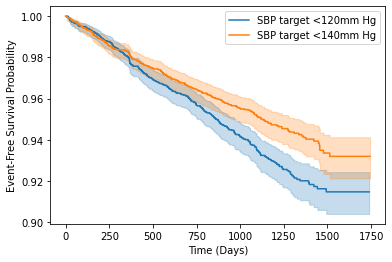

In [22]:
from auton_survival import reporting
import matplotlib.pyplot as plt
axx = reporting.plot_kaplanmeier(outcomes, intervention == 'SBP target <120mm Hg')
h, l = axx.get_legend_handles_labels()
plt.xlabel('Time (Days)')
plt.ylabel('Event-Free Survival Probability')
plt.legend([h[0], h[1]], ['SBP target <120mm Hg', 'SBP target <140mm Hg'], loc="upper right")
plt.show()
pass

In [36]:
def load_aimhigh_trial_data(outcome, intervention='RandAssi'):
  
  """Helper function to load and preprocess the AIM-HIGH dataset.

  The AIM-HIGH Dataset is a subset of 3,414 participants of the well known
  Atherothrombosis Intervention in Metabolic Syndrome with Low HDL/High Triglycerides 
  (AIM-HIGH) Trial [1] for studying extended-release niacin added to simvastatin to raise 
  low levels of high-density lipoprotein (HDL) cholesterol in reducing residual cardiovascular risk
  in patients with established cardiovascular disease. It is a popular dataset for longitudinal 
  survival analysis with time dependent covariates.

  References
  ----------
  [1]“Niacin in Patients with Low HDL Cholesterol Levels Receiving Intensive Statin Therapy,” 
  New England Journal of Medicine, vol. 365, no. 24. pp. 2255–2267, Nov. 15, 2011.

  Website and Documentation
  ----------
  [1] https://biolincc.nhlbi.nih.gov/studies/aimhigh/
  [2] https://biolincc.nhlbi.nih.gov/media/studies/aimhigh/data_dictionary/AIM_HIGH_V5.pdf?link_time=2022-07-08_14:24:59.314188
  """

  cat_feat = ['RandAssi', 'Age65', 'Sex', 'Race', 'ethn', 
              'Smoke', 'HxDiab', 'MetabSyn', 'StatinDuration']

  num_feat = ['Age', 'BMI', 'SysBP', 'DiasBP', 'LDL_C_Base', 
              'HDL_C_Base', 'Trig_Base', 'Glucose_Base', 'Lpa']

  all_feats = list(set(cat_feat + num_feat))

  features = {'patient.sas7bdat': all_feats}

  outcomedt = 'ET'+outcome
  outcome = 'VS'+outcome

  outcomes, features = datasets._load_generic_biolincc_dataset(outcome_tbl='patient.sas7bdat', 
                                                      time_col=outcomedt, 
                                                      event_col=outcome,
                                                      features=features, 
                                                      id_col='PatientKey',
                                                      location='datasets/AIMHIGH/')
  
  cat_feat = [cat_feat for cat_feat in cat_feat if cat_feat is not intervention]
  all_feats = list(set(cat_feat + num_feat))

  intervention = features[intervention]
  features = features[all_feats]

  intervention[intervention == 1.0] = 'Niacin'
  intervention[intervention == 0.0] = 'Placebo'

  # Convert Censoring Indicator to Binary
  # ie. 1 = Event, 0 = Censored
  outcomes.event = outcomes.event == 1.0 
  
  NaNindex = pd.isna(outcomes.time)
  outcomes = outcomes.loc[~NaNindex]
  features = features.loc[~NaNindex]

  features = features.rename(columns={"Age65": "Baseline_>65_years_old", 
                                      "ethn": "Ethnicity",
                                      "Smoke": "Baseline_Smoke_status",
                                      "HxDiab": "Baseline_History_Diabetes",
                                      "MetabSyn": "Baseline_Metabolic_Syndrome",
                                      "StatinDuration": "Baseline_Duration_statin_therapy_before_entry", 
                                      "SysBP": "Baseline_Seated_Systolic_Blood_Pressure",
                                      "DiasBP": "Baseline_Seated_Diastolic_Blood_Pressure", 
                                      "LDL_C_Base": "Baseline_LDL_Cholesterol",
                                      "HDL_C_Base": "Baseline_HDL_Cholesterol", 
                                      "Trig_Base": "Baseline_Triglycerides",
                                      "Glucose_Base": "Baseline_Glucose", 
                                      "Lpa": "Baseline_lipoprotein(a)",
                                      "Age": "Baseline_Age",
                                      "BMI": "Baseline_BMI"})

  features['Sex'].replace({0.0: "Female", 1.0: "Male"}, inplace=True)
  features['Baseline_Smoke_status'].replace({1.0: "Never", 2.0: "Current", 3.0: "Smokeless", 4.0: "Former"}, inplace=True)
  features['Ethnicity'].replace({0.0: "Not Hispanic or Latino", 1.0: "Hispanic or Latino"}, inplace=True)
  features['Race'].replace({3.0: "African American", 5.0: "White", 8.0: "Multi-racial or other"}, inplace=True)
  features['Baseline_Duration_statin_therapy_before_entry'].replace({0.0: "Not_on_statin", 1.0: "<1 year", 2.0: "1-5 year", 
                                                            3.0: ">5 year"}, inplace=True)

  cols = ['Baseline_>65_years_old',
          'Baseline_History_Diabetes',
          'Baseline_Metabolic_Syndrome']

  for col in cols:
    features[col].replace({1.0: "Yes", 0.0: "No"}, inplace=True)

  cat_feats = cols + ["Sex", 
                      "Race",
                      "Ethnicity",
                      "Baseline_Smoke_status",
                      "Baseline_Duration_statin_therapy_before_entry"]

  num_feats = ["Baseline_Age", 
               "Baseline_BMI", 
               "Baseline_Systolic_Blood_Pressure",
               "Baseline_Diastolic_Blood_Pressure",
               "Baseline_LDL_Cholesterol",
               "Baseline_HDL_Cholesterol",
               "Baseline_Triglycerides",
               "Baseline_Glucose",
               "Baseline_lipoprotein(a)"]

  return outcomes, features, intervention, cat_feats, num_feats

In [37]:
outcomes, features, intervention, cat_feats, num_feats = load_aimhigh_trial_data(outcome='Primary')

(4273, 18)


In [18]:
features.to_csv('feataimhigh.csv')

In [38]:
outcomes

,time,event
PatientKey,,
1.0,1930.0,False
2.0,1986.0,False
3.0,1984.0,False
7.0,1919.0,False
9.0,1916.0,False
...,...,...
8157.0,498.0,False
8158.0,450.0,False
8159.0,430.0,False


c:\Users/ASUS/Documents/GitHub/retrospective_t2e_analysis/auton-survival\auton_survival\reporting.py:43: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  curves[group] = KaplanMeierFitter().fit(outcomes[groups==group]['time'],
c:\Users/ASUS/Documents/GitHub/retrospective_t2e_analysis/auton-survival\auton_survival\reporting.py:44: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  outcomes[groups==group]['event'])
c:\Users/ASUS/Documents/GitHub/retrospective_t2e_analysis/auton-survival\auton_survival\reporting.py:43: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  curves[group] = KaplanMeierFitter().fit(outcomes[groups==group]['time'],
c:\Users/ASUS/Documents/GitHub/retrospective_t2e_analysis/auton-survival\auton_survival\reporting.py:44: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  outcomes[groups==group]['event'])


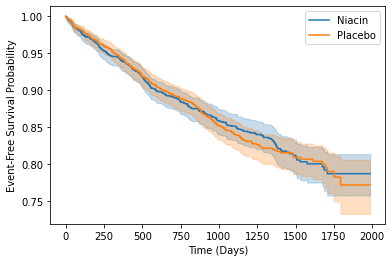

In [40]:
from auton_survival import reporting
import matplotlib.pyplot as plt
axx = reporting.plot_kaplanmeier(outcomes, intervention =='Niacin')
h, l = axx.get_legend_handles_labels()
plt.xlabel('Time (Days)')
plt.ylabel('Event-Free Survival Probability')
plt.legend([h[0], h[1]], ['Niacin', 'Placebo'], loc="upper right")
plt.show()
pass

In [50]:
def load_oat_trial_data(outcome, intervention='TRT_GRP'):
  
  """Helper function to load and preprocess the OAT dataset.

  The OAT Dataset is a subset of 2,166 participants of the well known
  Occluded Artery Trial (OAT) [1] for studying percutaneous coronary intervention (PCI)
  in reducing the risk of subsequent events in patients with persistent total occlusion 
  of the infarct-related coronary artery. It is a popular dataset for longitudinal 
  survival analysis with time dependent covariates.

  References
  ----------
  [1]J. S. Hochman et al., “Coronary Intervention for Persistent Occlusion after Myocardial Infarction,” 
  New England Journal of Medicine, vol. 355, no. 23, pp. 2395–2407, 2006, doi: 10.1056/NEJMoa066139.

  Website and Documentation
  -------------
  [1] https://biolincc.nhlbi.nih.gov/studies/oat/
  [2] https://biolincc.nhlbi.nih.gov/media/studies/oat/data_dictionary/OAT.pdf?link_time=2022-07-08_14:56:28.860985

  """

  cat_feat = ['TRT_GRP', 'age65', 'male', 'diabhx', 'anginahx', 
               'mihx', 'htenhx', 'killip24', 'finalrace', 
               'newq', 'stelev', 'hiECGriskR', 'multi', 'collany', 
               'EFall50', 'iraall', 'ladall', 'EFall40', 'pregrade',
               'cerevashx', 'pvdhx', 'chfhx', 'pcihx', 'cabghx', 
               'insulin', 'cursmoke', 'nyharand', 'thromb', 'strestst', 
               'stira', 'nitrat1d', 'bbd', 'ccbd', 'aspirind', 
               'ticlopd', 'clopidd', 'warfrnd', 'digoxind', 'diurd', 
               'spirod', 'insulind', 'orhypogd', 'lipidlod', 'eitherd',
               'acearbd', 'atleast1', 'atleast2', 'asporclopd', 'aspandclopd']

  num_feat = ['age', 'EFall', 'ckd']

  all_feats = list(set(cat_feat + num_feat))

  features = {'oat2166.sas7bdat': all_feats}

  outcomedt = outcome+'days'
  outcome = outcome+'fv'

  outcomes, features = datasets._load_generic_biolincc_dataset(outcome_tbl='oat2166.sas7bdat', 
                                                      time_col=outcomedt, 
                                                      event_col=outcome,
                                                      features=features, 
                                                      id_col='NEWID',
                                                      location='datasets/OAT/Ancillary/')
  
  cat_feat = [cat_feat for cat_feat in cat_feat if cat_feat is not intervention]
  all_feats = list(set(cat_feat + num_feat))

  intervention = features[intervention]
  features = features[all_feats]

  intervention[intervention == '1'] = 'Percutaneous coronary intervention'
  intervention[intervention == '2'] = 'Medical therapy alone'
    
  # Convert Censoring Indicator to Binary
  # ie. 1 = Event, 0 = Censored
  outcomes.event = outcomes.event == 1.0 
  
  NaNindex = pd.isna(outcomes.time)
  outcomes = outcomes.loc[~NaNindex]
  features = features.loc[~NaNindex]

  features = features.rename(columns={"age65": "Baseline_>65_years_old",
                                      "male": "Sex", 
                                      "diabhx": "Baseline_History_Diabetes",
                                      "anginahx": "Baseline_History_Angina",
                                      "mihx": "Baseline_History_Myocardial_Infarction",
                                      "htenhx": "Baseline_History_Hypertension",
                                      "killip24": "Baseline_Highest_Killip_Class_during_Index_Myocardial_infarction",
                                      "finalrace": "Race", 
                                      "newq": "Baseline_New_Q_Waves",
                                      "stelev": "Baseline_ST-Segment_Elevation",
                                      "hiECGriskR": "Baseline_ST-Segment_Elevation/Q-Wave/R-Wave_Loss",
                                      "multi": "Baseline_Multi_Vessel_Disease",
                                      "collany": "Baseline_Collaterals",
                                      "ckd": "Baseline_Estimated_Glomerular_Filtration_Rate",
                                      "EFall50": "Baseline_Ejection_Fraction_50",
                                      "iraall": "Baseline_Infarct_Related_Artery",
                                      "ladall": "Baseline_IRA=Left_Anterior_Descending",
                                      "EFall40": "Baseline_Ejection_Fraction_40",
                                      "cerevashx": "Baseline_History_Cerebrovascular_Disease",
                                      "pvdhx": "Baseline_History_Peripheral_Vessel_Disease",
                                      "chfhx": "Baseline_History_Heart_Failure",
                                      "pcihx": "Baseline_History_Percutaneous_Coronary_Intervention",
                                      "cabghx": "Baseline_History_Coronary_Artery_Bypass_Graft",
                                      "insulin": "Baseline_History_Insulin",
                                      "cursmoke": "Baseline_Smoke_status",  
                                      "nyharand": "Baseline_New_York_Heart_Association_Highest_Class",
                                      "thromb": "Baseline_Thrombolytic_Therapy",
                                      "strestst": "Baseline_Stress_Test",
                                      'stira': "Baseline_Ischemia_in_IRA_Territory", 
                                      'pregrade': "Baseline_TIMI_Flow_Grade_in_IRA", 
                                      'nitrat1d': "Baseline_Long-acting_Nitrates", 
                                      'bbd': "Baseline_Beta_Blocker", 
                                      'ccbd': "Baseline_Calcium_Blocker", 
                                      'aspirind': "Baseline_History_Aspirin", 
                                      'ticlopd': "Baseline_Ticlopidine", 
                                      'clopidd': "Baseline_Clopidogrel", 
                                      'warfrnd': "Baseline_Warfarin(Coumadin)", 
                                      'digoxind': "Baseline_Digoxin", 
                                      'diurd': "Baseline_Diuretic", 
                                      'spirod': "Baseline_Spironolactone", 
                                      'insulind': "Discharge_Insulin", 
                                      'orhypogd': "Baseline_Oral_Hypoclycemic", 
                                      'lipidlod': "Baseline_Lipid_Lowering_Therapy", 
                                      'eitherd': "Baseline_Thienopyridine",
                                      'acearbd': "Baseline_Angiotensin-converting-enzyme_Inhibitor_or_Angiotensin_Receptor_Blocker", 
                                      'atleast1': "Baseline_One_or_more_Aspirin_Warfarin_Thienopyridine", 
                                      'atleast2': "Baseline_Two_or_more_Aspirin_Warfarin_Thienopyridine", 
                                      'asporclopd': "Baseline_Aspirin_or_Thienopyridine", 
                                      'aspandclopd': "Baseline_Aspirin_plus_Thienopyridine",
                                      'age': "Baseline_Age",
                                      'EFall': "Baseline_Ejection_Fraction"})

  features["Sex"].replace({0.0: "Male", 1.0: "Female"}, inplace=True)
  features['Race'].replace({1.0: "White", 2.0: "Black", 3.0: "Hispanic", 4.0: "Other"}, inplace=True)
  features["Baseline_Infarct_Related_Artery"].replace({1.0: "Left anterior descending artery", 2.0: "Left circumflex artery", 
                                              3.0: "Right coronary artery"}, inplace=True)
  features["Baseline_IRA=Left_Anterior_Descending"].replace({0.0: "Other", 1.0: "Left anterior descending artery"}, inplace=True)
  features["Baseline_Multi_Vessel_Disease"].replace({0.0: "Single", 1.0: "Multi"}, inplace=True)
  features["Baseline_Ischemia_in_IRA_Territory"].replace({1.0: "Severe", 2.0: "Moderate", 3.0: "Mild", 4.0: "None"}, inplace=True)

  
  cols = ['Baseline_>65_years_old',
          'Baseline_History_Diabetes',
          'Baseline_History_Angina',
          'Baseline_History_Myocardial_Infarction',
          'Baseline_History_Hypertension',
          'Baseline_New_Q_Waves',
          'Baseline_ST-Segment_Elevation',
          'Baseline_ST-Segment_Elevation/Q-Wave/R-Wave_Loss',
          'Baseline_Collaterals',
          'Baseline_Ejection_Fraction_50',
          'Baseline_Ejection_Fraction_40',
          'Baseline_History_Cerebrovascular_Disease',
          'Baseline_History_Peripheral_Vessel_Disease',
          'Baseline_History_Heart_Failure',
          'Baseline_History_Percutaneous_Coronary_Intervention',
          'Baseline_History_Coronary_Artery_Bypass_Graft',
          'Baseline_History_Insulin',
          'Baseline_Smoke_status',
          'Baseline_Thrombolytic_Therapy',
          'Baseline_Stress_Test',
          'Baseline_Long-acting_Nitrates',
          'Baseline_Beta_Blocker',
          'Baseline_Calcium_Blocker',
          'Baseline_History_Aspirin',
          'Baseline_Ticlopidine',
          'Baseline_Clopidogrel',
          'Baseline_Warfarin(Coumadin)',
          'Baseline_Digoxin',
          'Baseline_Diuretic',
          'Baseline_Spironolactone',
          'Discharge_Insulin',
          'Baseline_Oral_Hypoclycemic',
          'Baseline_Lipid_Lowering_Therapy',
          'Baseline_Thienopyridine',
          'Baseline_Angiotensin-converting-enzyme_Inhibitor_or_Angiotensin_Receptor_Blocker',
          'Baseline_One_or_more_Aspirin_Warfarin_Thienopyridine',
          'Baseline_Two_or_more_Aspirin_Warfarin_Thienopyridine',
          'Baseline_Aspirin_or_Thienopyridine',
          'Baseline_Aspirin_plus_Thienopyridine']

  for col in cols:
    features[col].replace({1.0: "Yes", 0.0: "No"}, inplace=True)
  
  cat_feats = cols + ['Sex', 
                      'Baseline_Highest_Killip_Class_during_Index_Myocardial_infarction', 
                      'Race',
                      'Baseline_Multi_Vessel_Disease', 
                      'Baseline_Infarct_Related_Artery', 
                      'Baseline_IRA=Left_Anterior_Descending',
                      'Baseline_New_York_Heart_Association_Highest_Class', 
                      'Baseline_Ischemia_in_IRA_Territory',
                      'Baseline_TIMI_Flow_Grade_in_IRA']

  num_feats = ["Baseline_Age", 
               "Baseline_Ejection_Fraction", 
               "Baseline_Estimated_Glomerular_Filtration_Rate"]

  return outcomes, features, intervention, cat_feats, num_feats

In [51]:
outcomes, features, intervention, cat_feats, num_feats = load_oat_trial_data(outcome='comb')

(2166, 52)


c:\Users\ASUS\Documents\GitHub\retrospective_t2e_analysis\auton-survival\auton_survival\gls\datasets.py:12: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df.loc[:, col] = df[col].values.astype(str)


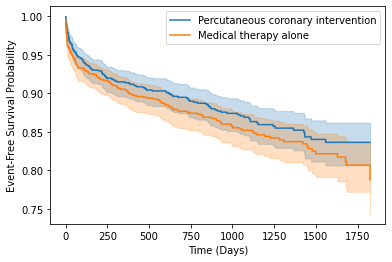

In [53]:
from auton_survival import reporting
import matplotlib.pyplot as plt
axx = reporting.plot_kaplanmeier(outcomes, intervention =='Percutaneous coronary intervention')
h, l = axx.get_legend_handles_labels()
plt.xlabel('Time (Days)')
plt.ylabel('Event-Free Survival Probability')
plt.legend([h[0], h[1]], ['Percutaneous coronary intervention', 'Medical therapy alone'], loc="upper right")
plt.show()
pass

In [46]:
features.to_csv('featoat.csv')

In [116]:
def load_peace_trial_data(outcome, intervention='TX'):

  """Helper function to load and preprocess the PEACE dataset.

  The PEACE Dataset is a subset of 8,290 participants of the well known
  Prevention of Events with Angiotensin Converting Enzyme Inhibition (PEACE) Trial [1] 
  for studying the benefit of Angiotensin-converting–enzyme (ACE) inhibitors in
  reducing atherosclerotic complications in patients who have vascular disease
  without heart failure. It is a popular dataset for longitudinal survival analysis 
  with time dependent covariates.

  References
  ----------
  [1]“Angiotensin-Converting–Enzyme Inhibition in Stable Coronary Artery Disease,” 
  New England Journal of Medicine, vol. 351, no. 20, pp. 2058–2068, Nov. 2004, doi: 10.1056/NEJMoa042739.

  Website and Documentation
  -------------
  [1] https://biolincc.nhlbi.nih.gov/studies/peace/
  [2] https://biolincc.nhlbi.nih.gov/media/studies/peace/data_dictionary/Peace.pdf?link_time=2022-07-08_11:28:53.661218

  """

  feature_list = {
    'prerand.sas7bdat' : ['AGE', 'EGFR', 'GENDER', 'PHDIZZ', 'PHSYNC', 'SER_CHOL', 'SER_POT'],
    'rand.sas7bdat' : ['ANARRC', 'ANTICO', 'ASANT', 'BEBLOC', 'CALCBL', 'CIGARE', 'CMOTH', 'COUGH', 'DICONL',
                      'DIGITS', 'HIANGINA', 'HICCABG', 'HICLAUDI', 'HIDIABET', 'HIHYPERT', 'HIMI', 'HIPTCA', 
                      'HISTROKE', 'HITIA', 'HPREP', 'INSLIN', 'LIPLOW', 'POSPDI', 'SDIABP', 'LVEDOC', 'LVEEJF',
                      'SKINRA', 'SYNCOP', 'TX', 'WT_KG', 'HT_CM', 'DIABTC', 'DIZZIN', 'HEADAC', 'HIANGIOG',
                      'MOTHER', 'NSYANG', 'ORAGEN', 'OTDIUR', 'QUALAB', 'QUANEF', 'SSYSBP']
  }

  if outcome is 'PRIMARY': outcomedt = 'PRIMRYDT'
  else: outcomedt = outcome+'DT'

  outcomes, _ = datasets._load_generic_biolincc_dataset('outcomes.sas7bdat', 
                                                outcomedt, outcome,
                                                features=feature_list, 
                                                id_col='NEW_ID',
                                                location='datasets/PEACE/Data/')
                                                                  
  outcomes2, features = datasets._load_generic_biolincc_dataset('outcomes.sas7bdat', 
                                                       'DAYSSINCERAND', outcome,
                                                        features=feature_list, 
                                                        id_col='NEW_ID',
                                                        location='datasets/PEACE/Data/')

  # When the outcome occurs we use the time to the outcome. 
  # Incase the outcome doesn't occur, we consider the time since randomization
  # to last followup as the censoring time.
  outcomes.loc[outcomes.event == 0.0, 'time'] = outcomes2.loc[outcomes.event == 0.0,'time']

  # Convert Censoring Indicator to Binary
  # ie. 1 = Event, 0 = Censored
  outcomes.event = outcomes.event == 1.0 

  NaNindex = pd.isna(outcomes.time)
  outcomes = outcomes.loc[~NaNindex]
  features = features.loc[~NaNindex]
  
  intervention = features[intervention]

  intervention[intervention == 1.0] = 'Trandolapril'
  intervention[intervention == 0.0] = 'Placebo'
  
  features = features.loc[:, features.columns != 'TX']

  features = features.rename(columns={"AGE": "Baseline_Age",
                                      "PHDIZZ": "Baseline_History_Dizziness",
                                      "EGFR": "Baseline_Estimated_Glomerular_Filtration_Rate",
                                      "GENDER": "Sex",
                                      "PHSYNC": "Baseline_History_Syncope",
                                      "SER_POT": "Baseline_Potassium",
                                      "SER_CHOL": "Baseline_Total_Cholesterol", 
                                      "ASANT": "Baseline_History_Aspirin", 
                                      "CIGARE": "Baseline_Smoke_status", 
                                      "ANARRC": "Baseline_Use_Anti_Arrhythmic", 
                                      "ANTICO": "Baseline_Use_Anticoagulants", 
                                      "BEBLOC": "Baseline_Beta_Blocker", 
                                      "CALCBL": "Baseline_Calcium_Blocker", 
                                      "CMOTH": "Baseline_Use_Other_Cardiac_Medication", 
                                      "COUGH": "Baseline_Cough",
                                      "HIDIABET": "Baseline_History_Diabetes", 
                                      "DICONL": "Baseline_Use_Diet_Control", 
                                      "DIGITS": "Baseline_Use_Digitalis", 
                                      "DIZZIN": "Baseline_Dizziness",
                                      "HEADAC": "Baseline_Headache",
                                      "HIANGINA": "Baseline_History_Angina",
                                      "HIANGIOG": "Baseline_Angiographic_Coronary_Disease",
                                      'HICCABG': "Baseline_History_Coronary_Artery_Bypass_Graft", 
                                      'HICLAUDI': "Baseline_History_Intermittent_Claudication", 
                                      'HIHYPERT': "Baseline_History_Hypertension", 
                                      'HIMI': "Baseline_History_Myocardial_Infarction", 
                                      'HIPTCA': "Baseline_History_Percutaneous_Coronary_Intervention", 
                                      'HISTROKE': "Baseline_History_Stroke", 
                                      'HITIA': "Baseline_History_Transient_Ischemic_Attack", 
                                      'HPREP': "Baseline_Use_Hormone_Replacement_Therapy", 
                                      'INSLIN': "Baseline_History_Insulin", 
                                      'LIPLOW': "Baseline_Lipid_Lowering_Therapy",
                                      "LVEDOC": "Baseline_Left_Ventricular_Evaluation_Documented_By",
                                      "LVEEJF": "Baseline_Left_Ventricular_Ejection_Fraction",
                                      "MOTHER": "Baseline_Use_Other_Noncardiac_Medication",
                                      "NSYANG": "Baseline_Canadian_Cardiovascular_Society_Classification",
                                      "ORAGEN": "Baseline_Use_Oral_Agents",
                                      "OTDIUR": "Baseline_Use_Other_Diuretics", 
                                      'WT_KG': "Baseline_Weight_KG", 
                                      'HT_CM': "Baseline_Height_CM",
                                      'POSPDI': "Baseline_Use_Potassium_Sparing_Diuretics", 
                                      "QUALAB": "Baseline_Left_Ventricular_Function_Qualitative_Abnormal",
                                      "QUANEF": "Baseline_Ejection_Fraction",
                                      'SKINRA': "Baseline_Skin_Rash", 
                                      'SYNCOP': "Baseline_History_Syncope",
                                      'SDIABP': "Baseline_Seated_Diastolic_Blood_Pressure",
                                      'SSYSBP': "Baseline_Seated_Systolic_Blood_Pressure"})
  
  features["Sex"].replace({1.0: "Female", 2.0: "Male"}, inplace=True)
  features['Baseline_Smoke_status'].replace({1.0: "Current", 2.0: "Ever", 3.0: "Never"}, inplace=True)
  features['Baseline_Left_Ventricular_Evaluation_Documented_By'].replace({1.0: "Contrast_Ventriculography", 
                                                                 2.0: "Radionuclide_Ventriculography", 
                                                                 3.0: "Echocardiogram"}, inplace=True)
  features['Baseline_Canadian_Cardiovascular_Society_Classification'].replace({1.0: "No symptoms of angina", 2.0: "I", 
                                                                      3.0: "II", 4.0: "III+", 5.0: "III+"}, inplace=True)

  cols = ['Baseline_History_Dizziness', 
          'Baseline_History_Syncope', 
          'Baseline_History_Aspirin', 
          'Baseline_Use_Anti_Arrhythmic', 
          'Baseline_Use_Anticoagulants', 
          'Baseline_Beta_Blocker', 
          'Baseline_Calcium_Blocker', 
          'Baseline_Use_Other_Cardiac_Medication',
          'Baseline_Cough',
          'Baseline_History_Diabetes', 
          'Baseline_Dizziness',
          'Baseline_Headache',
          'Baseline_Use_Diet_Control', 
          'Baseline_Use_Digitalis', 
          'Baseline_History_Angina', 
          'Baseline_Angiographic_Coronary_Disease',
          'Baseline_History_Coronary_Artery_Bypass_Graft', 
          'Baseline_History_Intermittent_Claudication', 
          'Baseline_History_Hypertension', 
          'Baseline_History_Myocardial_Infarction', 
          'Baseline_History_Percutaneous_Coronary_Intervention', 
          'Baseline_History_Stroke', 
          'Baseline_History_Transient_Ischemic_Attack', 
          'Baseline_Use_Hormone_Replacement_Therapy', 
          'Baseline_History_Insulin', 
          'Baseline_Use_Other_Noncardiac_Medication',
          'Baseline_Lipid_Lowering_Therapy', 
          'Baseline_Use_Potassium_Sparing_Diuretics', 
          'Baseline_Skin_Rash', 
          'Baseline_History_Syncope',
          'Baseline_Use_Oral_Agents',
          'Baseline_Use_Other_Diuretics',
          'Baseline_Left_Ventricular_Function_Qualitative_Abnormal',
          'Baseline_Ejection_Fraction']
  
  for col in cols:
    features[col].replace({1.0: "Yes", 2.0: "No"}, inplace=True)
  
  cat_feats = cols + ['Sex', 
                      'Baseline_Smoke_status', 
                      'Baseline_Left_Ventricular_Evaluation_Documented_By',
                      'Baseline_Canadian_Cardiovascular_Society_Classification']

  num_feats = ['Baseline_Age', 
               'Baseline_Seated_Diastolic_Blood_Pressure', 
               'Baseline_Estimated_Glomerular_Filtration_Rate', 
               'Baseline_Total_Cholesterol', 
               'Baseline_Potassium', 
               'Baseline_Seated_Systolic_Blood_Pressure', 
               'Baseline_Left_Ventricular_Ejection_Fraction',
               'Baseline_Height_CM', 
               'Baseline_Weight_KG']

  return outcomes, features, intervention, cat_feats, num_feats

<>:33: SyntaxWarning: "is" with a literal. Did you mean "=="?
<>:33: SyntaxWarning: "is" with a literal. Did you mean "=="?
C:\Users\ASUS\AppData\Local\Temp\ipykernel_29184\3650088895.py:33: SyntaxWarning: "is" with a literal. Did you mean "=="?
  if outcome is 'PRIMARY': outcomedt = 'PRIMRYDT'


In [117]:
outcomes, features, intervention, cat_feats, num_feats = load_peace_trial_data(outcome='PRIMARY')

(8290, 7)
(8290, 42)
(8290, 7)
(8290, 42)


C:\Users\ASUS\AppData\Local\Temp\ipykernel_29184\3650088895.py:116: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  features["Sex"].replace({1.0: "Female", 2.0: "Male"}, inplace=True)
C:\Users\ASUS\AppData\Local\Temp\ipykernel_29184\3650088895.py:117: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  features['Baseline_Smoke_status'].replace({1.0: "Current", 2.0: "Ever", 3.0: "Never"}, inplace=True)
C:\Users\ASUS\AppData\Local\Temp\ipykernel_29184\3650088895.py:118: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/panda

In [118]:
features.Baseline_Dizziness.value_counts()

2.0    7631
1.0     658
Name: Baseline_Dizziness, dtype: int64

In [119]:
features.Baseline_History_Dizziness.value_counts()

2.0    7141
1.0    1143
Name: Baseline_History_Dizziness, dtype: int64

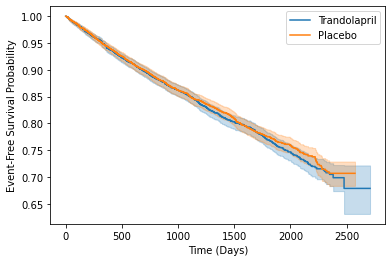

In [49]:
from auton_survival import reporting
import matplotlib.pyplot as plt
axx = reporting.plot_kaplanmeier(outcomes, intervention =='Trandolapril')
h, l = axx.get_legend_handles_labels()
plt.xlabel('Time (Days)')
plt.ylabel('Event-Free Survival Probability')
plt.legend([h[0], h[1]], ['Trandolapril', 'Placebo'], loc="upper right")
plt.show()
pass

In [162]:
def load_accord(location='', endpoint=None, features=None):  

  # Default Baseline Features to include: 
  if features is None:

    print("No Features Specified!! using default baseline features.")

    features = {
      
                'ACCORD/3-Data Sets - Analysis/3a-Analysis Data Sets/accord_key.sas7bdat': ['female', 'baseline_age', 
                                                                                            'arm', 
                                                                                            'raceclass', 'treatment'],
                
                'ACCORD/3-Data Sets - Analysis/3a-Analysis Data Sets/bloodpressure.sas7bdat': ['sbp', 'dbp', 'hr'],

                'ACCORD/4-Data Sets - CRFs/4a-CRF Data Sets/f01_inclusionexclusionsummary.sas7bdat': ['x1diab', 'x2mi', 
                'x2stroke', 'x2angina','cabg','ptci','cvdhist','orevasc','x2hbac11','x2hbac9','x3malb','x3lvh','x3sten',
                'x4llmeds','x4gender','x4hdlf', 'x4hdlm','x4bpmeds','x4notmed','x4smoke','x4bmi'],
                
                'ACCORD/3-Data Sets - Analysis/3a-Analysis Data Sets/lipids.sas7bdat': ['chol', 'trig', 'vldl', 'ldl', 'hdl'],
                                
                'ACCORD/3-Data Sets - Analysis/3a-Analysis Data Sets/otherlabs.sas7bdat': ['fpg', 'alt', 'cpk', 
                                                                                         'potassium', 'screat', 'gfr',
                                                                                         'ualb', 'ucreat', 'uacr'],
                }
           
                
    # outcomes  = {'ACCORD_Private/Data Sets - Analysis 201604/CVDOutcomes_201604.sas7bdat':['censor_po','type_po',                                                   
    #                                             'fuyrs_po', 'fuyrs_po7p', 'censor_tm', 'type_tm', 
    #                                             'fuyrs_tm', 'fuyrs_tm7p', 'censor_cm', 'type_nmi', 'fuyrs_nmi7p', 'censor_nst',
    #                                             'type_nst', 'fuyrs_nst', 'fuyrs_nst7p', 'censor_tst', 'fuyrs_tst', 'fuyrs_tst7p'
    #                                             'censor_chf', 'fuyrs_chf', 'censor_ex', 'type_ex', 'fuyrs_ex', 'fuyrs_ex7p', 
    #                                             'censor_maj', 'type_maj', 'fuyrs_maj7p']
    #               }
        
  if endpoint is None:
    print("No Endpoint specified, using primary study endpoint.")
    endpoint = 'po'

  # Set the outcome variable,
  event = 'censor_'+endpoint
  time = 'fuyrs_'+endpoint

  outcome_tbl = 'ACCORD/3-Data Sets - Analysis/3a-Analysis Data Sets/cvdoutcomes.sas7bdat'

  outcomes, features = datasets._load_generic_biolincc_dataset(outcome_tbl=outcome_tbl, 
                                                      time_col=time, 
                                                      event_col=event,
                                                      features=features,
                                                      id_col='MaskID',
                                                      location=location, 
                                                      visit_col='Visit', 
                                                      baseline_visit=(b'BLR', b'S01'))
  outcomes['event'] = 1-outcomes['event'] 
  outcomes['time'] = outcomes['time']

  outcomes = outcomes.loc[outcomes['time']>1.0]
  features = features.loc[outcomes.index]

  outcomes['time'] = outcomes['time']-1 

  return outcomes, features


def load_accord_dataset(intervention='Glycemia', random_seed=0, **kwargs):

  """Helper function to load and preprocess the ACCORD dataset.

  The ACCORD Dataset is a subset of 10,251 participants of the well known
  Action to Control Cardiovascular Risk in Diabetes (ACCORD) trial 
  [1] to determine whether a strategy of targeting normal glycated hemoglobin levels 
  would reduce the risk of serious cardiovascular events in middle-aged and 
  elderly people with type 2 diabetes mellitus, glycated hemoglobin levels of 7.5% or more, 
  and additional cardiovascular risk factors. It is a popular dataset for longitudinal survival 
  analysis with time dependent covariates.

  References
  ----------
  [1]“Long-Term Effects of Intensive Glucose Lowering on Cardiovascular Outcomes,” 
  New England Journal of Medicine, vol. 364, no. 9, pp. 818–828, Mar. 2011, doi: 10.1056/NEJMoa1006524.

  Website and Documentation
  ----------
  [1] https://biolincc.nhlbi.nih.gov/studies/accord/
  [2] https://biolincc.nhlbi.nih.gov/media/studies/accord/data_dictionary/ACCORD_v2016a.pdf?link_time=2022-07-08_21:22:47.796768
  """

  assert intervention in ['Glycemia', 'Lipid', 'BP']

  endpoint = kwargs.get('endpoint', 'po')

  outcomes, features = load_accord(location='datasets/ACCORD/', endpoint=endpoint)
    
  BP_patients = (features.arm==1.0)|(features.arm==2.0)|(features.arm==3.0)|(features.arm==4.0)
  lipid_patients = ~BP_patients

  glycemic_interventions = (features['arm']==1)|(features['arm']==2)|(features['arm']==5)|(features['arm']==6)

  if intervention == 'Glycemia':
    interventions = glycemic_interventions
    interventions[interventions==True] = "Intensive Glycemia"
    interventions[interventions==False] = "Standard Glycemia"
  else:
    features['glycemic_arm'] = glycemic_interventions
  if intervention == 'BP':
    features = features.loc[BP_patients]
    outcomes = outcomes.loc[BP_patients]
    interventions = (features.arm==1) | (features.arm==3)
    interventions[interventions==True] = "Intensive BP"
    interventions[interventions==False] = "Standard BP" 

  elif intervention == 'Lipid':
    features = features.loc[lipid_patients]
    outcomes = outcomes.loc[lipid_patients]
    interventions = (features.arm==6) | (features.arm==8)
    interventions[interventions==True] = "Lipid Fibrate"
    interventions[interventions==False] = "Lipid Placebo"

  outcomes['time'] = outcomes['time']*365.25

  outcomes, features, interventions = shuffle(outcomes, features, interventions, random_state=random_seed) 

  cat_feat = ['female', 'raceclass','x1diab', 'x2mi', 
               'x2stroke', 'x2angina','cabg','ptci','cvdhist','orevasc','x2hbac11','x2hbac9',
               'x3malb','x3lvh','x3sten','x4llmeds','x4gender','x4hdlf', 'x4hdlm','x4bpmeds',
               'x4notmed','x4smoke','x4bmi']

  num_feat = ['baseline_age', 'sbp', 'dbp', 'hr', 'chol', 'trig', 'vldl', 
               'ldl', 'hdl','fpg', 'alt', 'cpk', 'potassium', 'screat', 'gfr',
               'ualb', 'ucreat', 'uacr'] 

  if intervention in ['BP', 'Lipid']:
    cat_feat.append('glycemic_arm')

  all_feats = list(set(cat_feat + num_feat))

  features = features[all_feats]

  features = features.rename(columns={"baseline_age": "Baseline_Age", 
                                      "dbp": "Baseline_Seated_Diastolic_Blood_Pressure", 
                                      "female": "Sex", 
                                      'hr': 'Baseline_Heart_Rate', 
                                      "sbp": "Baseline_Seated_Systolic_Blood_Pressure", 
                                      'ldl': 'Baseline_Low_Density_Lipoprotein',
                                      'hdl': 'Baseline_High_Density_Lipoprotein', 
                                      'fpg': 'Baseline_Fasting_Plasma_Glucose', 
                                      'alt': 'Baseline_Alanine_Transaminase',
                                      'cpk': 'Baseline_Creatine_Phosphokinase', 
                                      'potassium': 'Baseline_Potassium', 
                                      'gfr': 'Baseline_Estimated_Glomerular_Filtration_Rate',
                                      'ualb': 'Baseline_Urine_albumin', 
                                      'ucreat': 'Baseline_Urine_creatinine',
                                      'trig': 'Baseline_Triglycerides', 
                                      'screat': 'Baseline_Serum_creatinine', 
                                      'chol': 'Baseline_Total_Cholesterol',  
                                      'uacr': 'Baseline_Urine_albumin/creatinine_ratio', 
                                      'vldl': 'Baseline_Very_low_density_lipoprotein', 
                                      'raceclass': 'Race', 
                                      'x1diab': 'Baseline_History_Diabetes', 
                                      'x2mi': 'Baseline_History_Myocardial_Infarction', 
                                      'x2stroke': 'Baseline_History_Stroke', 
                                      'x2angina': 'Baseline_History_Angina',
                                      'cabg': 'Baseline_History_Coronary_Artery_Bypass_Graft',
                                      'ptci': 'Baseline_History_Percutaneous_Coronary_Intervention',
                                      'cvdhist': 'Baseline_History_Cardiovascular_Disease',
                                      'orevasc': 'Baseline_Prior_revascularization',
                                      'x2hbac11': 'Baseline_Hemoglobin_A1C_7.5%to11%',
                                      'x2hbac9': 'Baseline_Hemoglobin_A1C_7.5%to9%',
                                      'x3malb': 'Baseline_History_Albuminuria',
                                      'x3lvh': 'Baseline_History_Left_Ventricular_Hypertrophy',
                                      'x3sten': 'Baseline_Low_Ankle_Brachial_Index',
                                      'x4llmeds': 'Baseline_Lipid_Lowering_Therapy',
                                      'x4gender': 'Gender_for_low_HDL_Cholesterol',
                                      'x4hdlf': 'Baseline_HDL_Cholesterol_Female', 
                                      'x4hdlm': 'Baseline_HDL_Cholesterol_Male',
                                      'x4bpmeds': 'Baseline_On_Blood_Pressure_Medication',
                                      'x4notmed': 'Baseline_Not_On_Blood_Pressure_Medication',
                                      'x4smoke': 'Baseline_Smoke_status',
                                      'x4bmi': 'Baseline_BMI_>32'})
  
  features["Sex"].replace({0.0: "Male", 1.0: "Female"}, inplace=True)
  features["Gender_for_low_HDL_Cholesterol"].replace({2.0: "Male", 1.0: "Female"}, inplace=True)

  cols = ['Baseline_History_Myocardial_Infarction', 
          'Baseline_History_Stroke', 
          'Baseline_History_Angina', 
          'Baseline_History_Coronary_Artery_Bypass_Graft', 
          'Baseline_History_Percutaneous_Coronary_Intervention',
          'Baseline_History_Cardiovascular_Disease', 
          'Baseline_Prior_revascularization',
          'Baseline_Lipid_Lowering_Therapy', 
          'Baseline_HDL_Cholesterol_Female', 
          'Baseline_Smoke_status',
          'Baseline_HDL_Cholesterol_Male', 
          'Baseline_On_Blood_Pressure_Medication', 
          'Baseline_Not_On_Blood_Pressure_Medication', 
          'Baseline_BMI_>32']

  cols2 = ['Baseline_History_Diabetes', 
           'Baseline_Hemoglobin_A1C_7.5%to11%', 
           'Baseline_Hemoglobin_A1C_7.5%to9%']

  cols3 = ['Baseline_History_Albuminuria', 
           'Baseline_History_Left_Ventricular_Hypertrophy', 
           'Baseline_Low_Ankle_Brachial_Index']

  for col in cols:
    features[col].replace({1.0: "Yes", 2.0: "No"}, inplace=True)

  for col in cols2:
    features[col].replace({1.0: "Yes", 2.0: "No (Ineligible)"}, inplace=True)

  for col in cols3:
    features[col].replace({1.0: "Yes", 2.0: "No", 3.0: "Not Available"}, inplace=True)

  cat_feats = cols + cols2 + cols3 + ['Sex',
                                      'Race',
                                      'Gender_for_low_HDL_Cholesterol']

  num_feats = ['Baseline_Age', 
               'Baseline_Systolic_Blood_Pressure', 
               'Baseline_Diastolic_Blood_Pressure', 
               'Baseline_Heart_Rate', 
               'Baseline_Total_Cholesterol', 
               'Baseline_Triglycerides', 
               'Baseline_Very_low_density_lipoprotein', 
               'Baseline_LDL_Cholesterol', 
               'Baseline_Potassium',
               'Baseline_HDL_Cholesterol', 
               'Baseline_Fasting_Plasma_Glucose', 
               'Baseline_Alanine_Transaminase', 
               'Baseline_Creatine_Phosphokinase',
               'Baseline_Serum_creatinine', 
               'Baseline_Estimated_Glomerular_Filtration_Rate', 
               'Baseline_Urine_albumin', 
               'Baseline_Urine_albumin/creatinine_ratio',
               'Baseline_Urine_creatinine']

  return outcomes, features, interventions, cat_feats, num_feats

In [170]:
outcomes, features, interventions, cat_feats, num_feats = load_accord_dataset(intervention='Lipid')

No Features Specified!! using default baseline features.
(10251, 5)
(10205, 3)
(10251, 21)
(10197, 5)
(10240, 9)


c:\Users\ASUS\Documents\GitHub\retrospective_t2e_analysis\auton-survival\auton_survival\gls\datasets.py:12: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df.loc[:, col] = df[col].values.astype(str)
C:\Users\ASUS\AppData\Local\Temp\ipykernel_50452\2663221010.py:54: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  outcomes['event'] = 1-outcomes['event']
C:\Users\ASUS\AppData\Local\Temp\ipykernel_50452\2663221010.py:55: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Tr

In [173]:
outcomes

,time,event
MaskID,,
109052.0,1316.718184,0.0
100041.0,1814.241781,0.0
108663.0,1083.741781,0.0
106707.0,2191.500000,0.0
103485.0,1582.153964,0.0
...,...,...
109656.0,1070.732877,0.0
106228.0,19.256350,1.0
103059.0,1452.319195,0.0


In [171]:
features

,Baseline_BMI_>32,Baseline_History_Stroke,Baseline_Hemoglobin_A1C_7.5%to9%,Baseline_Potassium,Baseline_Seated_Diastolic_Blood_Pressure,Baseline_Alanine_Transaminase,Baseline_Total_Cholesterol,Baseline_History_Diabetes,Sex,Baseline_Age,...,Baseline_Hemoglobin_A1C_7.5%to11%,Baseline_Urine_albumin/creatinine_ratio,Baseline_Urine_albumin,Baseline_Fasting_Plasma_Glucose,Baseline_History_Coronary_Artery_Bypass_Graft,Baseline_Urine_creatinine,Baseline_On_Blood_Pressure_Medication,Baseline_Triglycerides,Baseline_History_Cardiovascular_Disease,Baseline_Prior_revascularization
MaskID,,,,,,,,,,,,,,,,,,,,,
109052.0,Yes,No,NaN,4.66,84.0,27.0,237.0,Yes,Female,63.7,...,Yes,0.7,0.41,228.0,No,0.586,Yes,199.0,No,No
100041.0,No,No,NaN,4.51,72.0,25.0,193.0,Yes,Male,62.2,...,Yes,180.6,117.00,139.0,No,0.648,Yes,179.0,No,No
108663.0,No,No,NaN,3.96,NaN,30.0,186.0,Yes,Male,58.5,...,Yes,1.0,0.47,157.0,No,0.457,Yes,158.0,No,No
106707.0,No,No,NaN,4.35,94.0,83.0,196.0,Yes,Male,68.8,...,Yes,3.7,3.99,166.0,No,1.091,No,227.0,No,No
103485.0,Yes,No,NaN,4.89,94.0,32.0,194.0,Yes,Female,55.6,...,Yes,0.8,1.19,169.0,No,1.475,Yes,232.0,No,No
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
109656.0,No,No,NaN,4.30,71.0,27.0,152.0,Yes,Male,69.7,...,Yes,0.4,0.68,106.0,No,1.708,Yes,177.0,No,No
106228.0,Yes,No,NaN,5.18,66.0,22.0,159.0,Yes,Male,58.7,...,Yes,84.0,58.30,200.0,No,0.694,Yes,241.0,Yes,No
103059.0,No,No,Yes,4.36,81.0,29.0,149.0,Yes,Male,55.6,...,NaN,0.3,0.37,126.0,No,1.312,Yes,117.0,No,No


In [172]:
interventions

MaskID
109052.0    Lipid Fibrate
100041.0    Lipid Placebo
108663.0    Lipid Placebo
106707.0    Lipid Placebo
103485.0    Lipid Placebo
                ...      
109656.0    Lipid Placebo
106228.0    Lipid Placebo
103059.0    Lipid Placebo
104957.0    Lipid Placebo
105205.0    Lipid Placebo
Name: arm, Length: 5278, dtype: object

In [106]:
'Lipid' in features

False

In [67]:
outcomes

,time,event
MaskID,,
103964.0,1591.089041,0.0
106889.0,2191.500000,1.0
103660.0,1839.258904,0.0
108622.0,1644.125342,0.0
108268.0,8.601516,1.0
...,...,...
108232.0,2191.500000,0.0
109630.0,1581.082192,0.0
105050.0,1230.842466,0.0


In [63]:
interventions

MaskID
103964.0     True
106889.0    False
103660.0    False
108622.0    False
108268.0     True
            ...  
108232.0     True
109630.0     True
105050.0    False
103389.0     True
102833.0     True
Name: arm, Length: 9822, dtype: bool

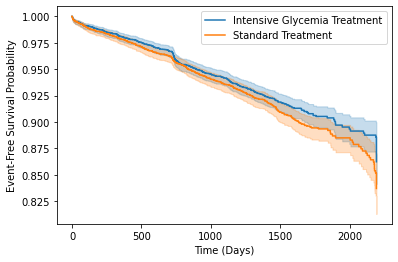

In [69]:
from auton_survival import reporting
import matplotlib.pyplot as plt
axx = reporting.plot_kaplanmeier(outcomes, interventions ==True)
h, l = axx.get_legend_handles_labels()
plt.xlabel('Time (Days)')
plt.ylabel('Event-Free Survival Probability')
plt.legend([h[0], h[1]], ['Intensive Glycemia Treatment', 'Standard Treatment'], loc="upper right")
plt.show()
pass

In [4]:
def load_bari2d(endpoint=None, features=None, location=''):

  if features is None:

    print("No Features Specified!! using default demographic features.")

    features = {'bari2d_bl.sas7bdat': ['strata', 'weight', 
                                       'bmi', 'age', 
                                       'sex', 'race'],
               } 

  if endpoint is None:
    print("No Endpoint specified, using all-cause death as the study endpoint.")
    endpoint = 'death'

  # Set the outcome variable
  event = endpoint

  if event[-3:] == 'dth': time = 'deathfu'
  else: time = event + 'fu'

  return datasets._load_generic_biolincc_dataset(outcome_tbl='bari2d_endpts.sas7bdat', 
                                        time_col=time, 
                                        event_col=event,
                                        features=features,
                                        id_col='id',
                                        location=location+'BARI2D/data/')

In [154]:
def load_bari_2d_dataset(location, intervention='cardtrt', random_seed=0, **kwargs):

  """Helper function to load and preprocess the BARI 2D dataset.

  The BARI 2D Dataset is a subset of 2,368 participants of the well known
  Bypass Angioplasty Revascularization Investigation 2 Diabetes (BARI 2D) trial 
  [1] to test treatment strategies for patients with coronary artery disease 
  and diabetes. It is a popular dataset for longitudinal survival analysis 
  with time dependent covariates.

  References
  ----------
  [1]“A Randomized Trial of Therapies for Type 2 Diabetes and Coronary Artery Disease,” 
  New England Journal of Medicine, vol. 360, no. 24, pp. 2503–2515, Jun. 2009, doi: 10.1056/NEJMoa0805796.


  Website and Documentation
  ----------
  [1] https://biolincc.nhlbi.nih.gov/studies/bari2d/
  [2] https://biolincc.nhlbi.nih.gov/media/studies/bari2d/data_dictionary/BARI2D_V4.pdf?link_time=2022-07-08_21:12:17.980218
  """

  assert intervention in ['cardtrt', 'diabtrt']

  endpoint = kwargs.get('endpoint', 'dthmistr')

  cat_feat = ['strata', 'hxmi', 'hxchf', 
              'hxhtn', 'hxchl', 'hxcva', 'betab',
              'nsgn', 'diur', 'acei', 'arb', 'asp',
              'hmg', 'biguanide', 'tzd', 'sulf', 'hxhypo',
              'sex', 'cardtrt', 'diabtrt',
              'smkcat', 'ccb', 'insulin', 'ablvef', 
              'qabn', 'stabn', 'tabn', 'priorstent', 
              'priorrev', 'hispanic', 'race', 'apa', 'abilow']

  num_feat = ['weight', 'sbp_stand', 'dbp_stand', 'screat', 
              'spotass', 'dmdur', 'insul_circ', 'hba1c', 'tchol',
              'hdl','ldl','trig', 'acr', 'age', 'bmi']

  all_feats = list(set(cat_feat + num_feat))

  features = {'bari2d_bl.sas7bdat': all_feats}

  outcomes, features = load_bari2d(location=location, features=features, endpoint=endpoint) 
  outcomes, features = shuffle(outcomes, features, random_state=random_seed) 

  features = features.rename(columns={'cardtrt': 'Cardiovascular_Treatment',
                                      'diabtrt': 'Glycemic_Arm_Treatment',
                                      "age": "Baseline_Age", 
                                      "dbp_stand": "Baseline_Standing_Diastolic_Blood_Pressure", 
                                      "sex": "Sex",  
                                      "sbp_stand": "Baseline_Standing_Systolic_Blood_Pressure", 
                                      "asp": "Baseline_History_Aspirin", 
                                      "smkcat": "Baseline_Smoke_status", 
                                      "betab": "Baseline_Beta_Blocker", 
                                      "ccb": "Baseline_Calcium_Blocker", 
                                      'hxhtn': "Baseline_History_Hypertension", 
                                      'hxmi': "Baseline_History_Myocardial_Infarction", 
                                      'insulin': "Baseline_History_Insulin", 
                                      'weight': "Baseline_Weight_KG",
                                      'bmi': 'Baseline_BMI', 
                                      'qabn': 'Baseline_Abnormal_Q-wave', 
                                      'trig': 'Baseline_Triglycerides', 
                                      'dmdur': 'Baseline_Duration_Diabetes_Mellitus', 
                                      'ablvef': 'Baseline_Left_ventricular_ejection_fraction<50%', 
                                      'race': 'Race', 
                                      'priorrev': 'Baseline_Prior_revascularization', 
                                      'hxcva': 'Baseline_History_Cerebrovascular_Disease', 
                                      'screat': 'Baseline_Serum_creatinine', 
                                      'hmg': 'Baseline_On_Statin', 
                                      'hxhypo': 'Baseline_History_Hypoglycemic', 
                                      'hba1c': 'Baseline_Hemoglobin_A1C', 
                                      'priorstent': 'Baseline_Prior_Stent', 
                                      'spotass': 'Baseline_Potassium',
                                      'hispanic': 'Ethnicity', 
                                      'tchol': 'Baseline_Total_Cholesterol',
                                      'hdl': 'Baseline_HDL_Cholesterol', 
                                      'strata': 'Baseline_Randomization_stratum', 
                                      'insul_circ': 'Baseline_Circulating_insulin',
                                      'tzd': 'Baseline_Thiazolidinedione', 
                                      'ldl': 'Baseline_LDL_Cholesterol', 
                                      'tabn': 'Baseline_Abnormal_T-waves',
                                      'nsgn': 'Baseline_Nonsublingual_nitrate', 
                                      'sulf': 'Baseline_Sulfonylurea', 
                                      'hxchf': 'Baseline_History_Heart_Failure',
                                      'arb': 'Baseline_Angiotensin_receptor_blocker', 
                                      'acr': 'Baseline_Urine_albumin/creatinine_ratio', 
                                      'diur': 'Baseline_Diuretic',
                                      'apa': 'Baseline_Anti-platelet', 
                                      'hxchl': 'Baseline_History_Hypercholesterolemia', 
                                      'acei': 'Baseline_Angiotensin-converting–enzyme_inhibitor',
                                      'abilow': 'Baseline_Low_Ankle_Brachial_Index', 
                                      'biguanide': 'Baseline_Biguanide', 
                                      'stabn': 'Baseline_Abnormal_Stress_Test_Depression'})
  
  features["Sex"].replace({1.0: "Male", 2.0: "Female"}, inplace=True)
  features["Race"].replace({1.0: "White", 2.0: "Non_White"}, inplace=True)
  features['Baseline_Smoke_status'].replace({0.0: "Never", 1.0: "Former", 2.0: "Current"}, inplace=True)
  features["Baseline_Randomization_stratum"].replace({'PCI': "Percutaneous Coronary Intervention", 
                                             'CABG': "Coronary Artery Bypass Graft"}, inplace=True)
  features["Glycemic_Arm_Treatment"].replace({1.0: "Insulin Providing", 0.0: "Insulin Sensitizing"}, inplace=True) 
  features["Cardiovascular_Treatment"].replace({1.0: "Early Revascularization", 0.0: "Medical Therapy"}, inplace=True)  

  cols = ['Baseline_History_Aspirin', 
          'Baseline_Prior_revascularization', 
          'Baseline_History_Cerebrovascular_Disease', 
          'Baseline_On_Statin', 
          'Baseline_History_Hypoglycemic', 
          'Baseline_Beta_Blocker', 
          'Baseline_Calcium_Blocker', 
          'Baseline_History_Hypertension', 
          'Baseline_Prior_Stent',
          'Baseline_History_Myocardial_Infarction', 
          'Baseline_History_Insulin', 
          'Baseline_Abnormal_Q-wave', 
          'Baseline_Left_ventricular_ejection_fraction<50%',
          'Ethnicity', 
          'Baseline_Thiazolidinedione', 
          'Baseline_Abnormal_T-waves', 
          'Baseline_Nonsublingual_nitrate', 
          'Baseline_Sulfonylurea',
          'Baseline_History_Heart_Failure', 
          'Baseline_Angiotensin_receptor_blocker', 
          'Baseline_Diuretic', 
          'Baseline_Anti-platelet', 
          'Baseline_History_Hypercholesterolemia',
          'Baseline_Angiotensin-converting–enzyme_inhibitor', 
          'Baseline_Low_Ankle_Brachial_Index', 
          'Baseline_Biguanide', 
          'Baseline_Abnormal_Stress_Test_Depression']

  for col in cols:
    features[col].replace({1.0: "Yes", 0.0: "No"}, inplace=True)
  
  if intervention=='cardtrt':
    intervention = features['Cardiovascular_Treatment']
    features = features.loc[:, features.columns != "Cardiovascular_Treatment"]
    cat_feats = cols + ["Baseline_Randomization_stratum", 
                      "Sex", 
                      "Baseline_Smoke_status", 
                      "Race",
                      "Glycemic_Arm_Treatment"]
  elif intervention=='diabtrt':
    intervention = features['Glycemic_Arm_Treatment']
    features = features.loc[:, features.columns != "Glycemic_Arm_Treatment"]
    cat_feats = cols + ["Baseline_Randomization_stratum", 
                      "Sex", 
                      "Baseline_Smoke_status", 
                      "Race",
                      "Cardiovascular_Treatment"]

  num_feats = ['Baseline_Weight_KG', 
               'Baseline_Standing_Systolic_Blood_Pressure', 
               'Baseline_Standing_Diastolic_Blood_Pressure', 
               'Baseline_Serum_creatinine', 
               'Baseline_Potassium', 
               'Baseline_Duration_Diabetes_Mellitus', 
               'Baseline_Circulating_insulin',
               'Baseline_Hemoglobin_A1C', 
               'Baseline_Total_Cholesterol', 
               'Baseline_HDL_Cholesterol', 
               'Baseline_LDL_Cholesterol',
               'Baseline_Triglycerides', 
               'Baseline_Urine_albumin/creatinine_ratio', 
               'Baseline_Age', 
               'Baseline_BMI']

  return outcomes, features, intervention, cat_feats, num_feats

In [159]:
outcomes, features, intervention, cat_feats, num_feats = load_bari_2d_dataset(location='datasets/', intervention='cardtrt')

(2368, 48)


c:\Users\ASUS\Documents\GitHub\retrospective_t2e_analysis\auton-survival\auton_survival\gls\datasets.py:12: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df.loc[:, col] = df[col].values.astype(str)


In [160]:
intervention

N4817            Medical Therapy
N2204            Medical Therapy
N3296            Medical Therapy
N4106            Medical Therapy
N3356            Medical Therapy
                  ...           
N2768            Medical Therapy
N3935    Early Revascularization
N2351            Medical Therapy
N2462    Early Revascularization
N3801    Early Revascularization
Name: Cardiovascular_Treatment, Length: 2368, dtype: object

In [161]:
features.shape

(2368, 47)

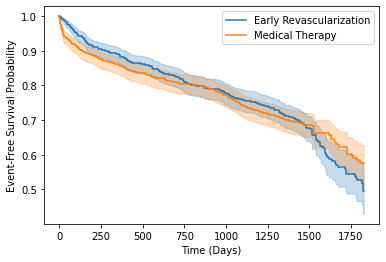

In [105]:
from auton_survival import reporting
import matplotlib.pyplot as plt
axx = reporting.plot_kaplanmeier(outcomes[outcomes.time <= 365.25*5], intervention[outcomes[outcomes.time <= 365.25*5].index] =='Early Revascularization')
h, l = axx.get_legend_handles_labels()
plt.xlabel('Time (Days)')
plt.ylabel('Event-Free Survival Probability')
plt.legend([h[0], h[1]], ['Early Revascularization', 'Medical Therapy'], loc="upper right")
plt.show()
pass

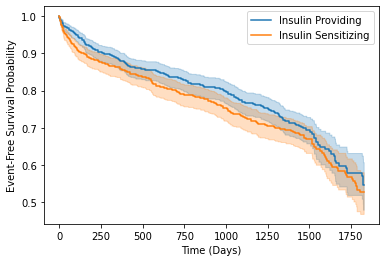

In [114]:
from auton_survival import reporting
import matplotlib.pyplot as plt
axx = reporting.plot_kaplanmeier(outcomes[outcomes.time <= 365.25*5], features['Baseline_Glycemic_arm_treatment'][outcomes[outcomes.time <= 365.25*5].index] =='Insulin Providing')
h, l = axx.get_legend_handles_labels()
plt.xlabel('Time (Days)')
plt.ylabel('Event-Free Survival Probability')
plt.legend([h[0], h[1]], ['Insulin Providing', 'Insulin Sensitizing'], loc="upper right")
plt.show()
pass

In [115]:
outcomes.event

N4817    1.0
N2204    0.0
N3296    1.0
N4106    0.0
N3356    1.0
        ... 
N2768    0.0
N3935    0.0
N2351    1.0
N2462    0.0
N3801    0.0
Name: event, Length: 2368, dtype: float64

In [144]:
def load_accord(location='', endpoint=None, features=None):  

  # Default Baseline Features to include: 
  if features is None:

    print("No Features Specified!! using default baseline features.")

    features = {
      
                'ACCORD/3-Data Sets - Analysis/3a-Analysis Data Sets/accord_key.sas7bdat': ['female', 'baseline_age', 
                                                                                            'arm', 
                                                                                            'raceclass', 'treatment'],
                
                'ACCORD/3-Data Sets - Analysis/3a-Analysis Data Sets/bloodpressure.sas7bdat': ['sbp', 'dbp', 'hr'],

                'ACCORD/4-Data Sets - CRFs/4a-CRF Data Sets/f01_inclusionexclusionsummary.sas7bdat': ['x1diab', 'x2mi', 
                'x2stroke', 'x2angina','cabg','ptci','cvdhist','orevasc','x2hbac11','x2hbac9','x3malb','x3lvh','x3sten',
                'x4llmeds','x4gender','x4hdlf', 'x4hdlm','x4bpmeds','x4notmed','x4smoke','x4bmi'],
                
                'ACCORD/3-Data Sets - Analysis/3a-Analysis Data Sets/lipids.sas7bdat': ['chol', 'trig', 'vldl', 'ldl', 'hdl'],
                                
                'ACCORD/3-Data Sets - Analysis/3a-Analysis Data Sets/otherlabs.sas7bdat': ['fpg', 'alt', 'cpk', 
                                                                                         'potassium', 'screat', 'gfr',
                                                                                         'ualb', 'ucreat', 'uacr'],
                }
           
                
    # outcomes  = {'ACCORD_Private/Data Sets - Analysis 201604/CVDOutcomes_201604.sas7bdat':['censor_po','type_po',                                                   
    #                                             'fuyrs_po', 'fuyrs_po7p', 'censor_tm', 'type_tm', 
    #                                             'fuyrs_tm', 'fuyrs_tm7p', 'censor_cm', 'type_nmi', 'fuyrs_nmi7p', 'censor_nst',
    #                                             'type_nst', 'fuyrs_nst', 'fuyrs_nst7p', 'censor_tst', 'fuyrs_tst', 'fuyrs_tst7p'
    #                                             'censor_chf', 'fuyrs_chf', 'censor_ex', 'type_ex', 'fuyrs_ex', 'fuyrs_ex7p', 
    #                                             'censor_maj', 'type_maj', 'fuyrs_maj7p']
    #               }
        
  if endpoint is None:
    print("No Endpoint specified, using primary study endpoint.")
    endpoint = 'po'

  # Set the outcome variable,
  event = 'censor_'+endpoint
  time = 'fuyrs_'+endpoint

  outcome_tbl = 'ACCORD/3-Data Sets - Analysis/3a-Analysis Data Sets/cvdoutcomes.sas7bdat'

  outcomes, features = datasets._load_generic_biolincc_dataset(outcome_tbl=outcome_tbl, 
                                                      time_col=time, 
                                                      event_col=event,
                                                      features=features,
                                                      id_col='MaskID',
                                                      location=location, 
                                                      visit_col='Visit', 
                                                      baseline_visit=(b'BLR', b'S01'))
  outcomes['event'] = 1-outcomes['event'] 
  outcomes['time'] = outcomes['time']

  outcomes = outcomes.loc[outcomes['time']>1.0]
  features = features.loc[outcomes.index]

  outcomes['time'] = outcomes['time']-1 

  return outcomes, features


def load_accord_dataset(intervention='Glycemia', random_seed=0, **kwargs):

  """Helper function to load and preprocess the ACCORD dataset.

  The ACCORD Dataset is a subset of 10,251 participants of the well known
  Action to Control Cardiovascular Risk in Diabetes (ACCORD) trial 
  [1] to determine whether a strategy of targeting normal glycated hemoglobin levels 
  would reduce the risk of serious cardiovascular events in middle-aged and 
  elderly people with type 2 diabetes mellitus, glycated hemoglobin levels of 7.5% or more, 
  and additional cardiovascular risk factors. It is a popular dataset for longitudinal survival 
  analysis with time dependent covariates.

  References
  ----------
  [1]“Long-Term Effects of Intensive Glucose Lowering on Cardiovascular Outcomes,” 
  New England Journal of Medicine, vol. 364, no. 9, pp. 818–828, Mar. 2011, doi: 10.1056/NEJMoa1006524.

  Website and Documentation
  ----------
  [1] https://biolincc.nhlbi.nih.gov/studies/accord/
  [2] https://biolincc.nhlbi.nih.gov/media/studies/accord/data_dictionary/ACCORD_v2016a.pdf?link_time=2022-07-08_21:22:47.796768
  """

  assert intervention in ['Glycemia', 'Lipid', 'Blood Pressure']

  endpoint = kwargs.get('endpoint', 'po')

  outcomes, features = load_accord(location='datasets/ACCORD/', endpoint=endpoint)
    
  BP_patients = (features.arm==1.0)|(features.arm==2.0)|(features.arm==3.0)|(features.arm==4.0)
  lipid_patients = ~BP_patients

  glycemic_interventions = (features['arm']==1)|(features['arm']==2)|(features['arm']==5)|(features['arm']==6)
  blood_pressure_interventions = (features.arm==1) | (features.arm==3)
  lipid_interventions = (features.arm==6) | (features.arm==8)

  if intervention == 'Glycemia':
    interventions = glycemic_interventions
    interventions[interventions==True] = "Intensive Glycemia"
    interventions[interventions==False] = "Standard Glycemia"

  elif intervention == 'Blood Pressure':
    # features = features.loc[BP_patients]
    # outcomes = outcomes.loc[BP_patients]
    interventions = blood_pressure_interventions
    interventions[interventions==True] = "Intensive Blood Pressure"
    interventions[interventions==False] = "Standard Blood Pressure"

  elif intervention == 'Lipid':
    # features = features.loc[lipid_patients]
    # outcomes = outcomes.loc[lipid_patients]
    interventions = lipid_interventions
    interventions[interventions==True] = "Lipid Fibrate"
    interventions[interventions==False] = "Lipid Placebo"

  outcomes['time'] = outcomes['time']*365.25

  outcomes, features, interventions = shuffle(outcomes, features, interventions, random_state=random_seed) 

  cat_feat = ['female', 'raceclass','x1diab', 'x2mi', 
               'x2stroke', 'x2angina','cabg','ptci','cvdhist','orevasc','x2hbac11','x2hbac9',
               'x3malb','x3lvh','x3sten','x4llmeds','x4gender','x4hdlf', 'x4hdlm','x4bpmeds',
               'x4notmed','x4smoke','x4bmi']

  num_feat = ['baseline_age', 'sbp', 'dbp', 'hr', 'chol', 'trig', 'vldl', 
               'ldl', 'hdl','fpg', 'alt', 'cpk', 'potassium', 'screat', 'gfr',
               'ualb', 'ucreat', 'uacr'] 

  # if intervention in ['Blood Pressure', 'Lipid']:
  #   cat_feat.append('Glycemic_Arm_Trial')

  all_feats = list(set(cat_feat + num_feat))

  features = features[all_feats]

  if intervention == 'Glycemia':
    features['Blood_Pressure_Trial'] = blood_pressure_interventions
    features['Lipid_Trial'] = lipid_interventions
  elif intervention == 'Blood Pressure':
    features['Lipid_Trial'] = lipid_interventions
    features['Glycemia_Trial'] = glycemic_interventions
  elif intervention == 'Lipid':
    features['Glycemia_Trial'] = glycemic_interventions
    features['Blood_Pressure_Trial'] = blood_pressure_interventions  

  features = features.rename(columns={"baseline_age": "Baseline_Age", 
                                      "dbp": "Baseline_Seated_Diastolic_Blood_Pressure", 
                                      "female": "Sex", 
                                      'hr': 'Baseline_Heart_Rate', 
                                      "sbp": "Baseline_Seated_Systolic_Blood_Pressure", 
                                      'ldl': 'Baseline_Low_Density_Lipoprotein',
                                      'hdl': 'Baseline_High_Density_Lipoprotein', 
                                      'fpg': 'Baseline_Fasting_Plasma_Glucose', 
                                      'alt': 'Baseline_Alanine_Transaminase',
                                      'cpk': 'Baseline_Creatine_Phosphokinase', 
                                      'potassium': 'Baseline_Potassium', 
                                      'gfr': 'Baseline_Estimated_Glomerular_Filtration_Rate',
                                      'ualb': 'Baseline_Urine_albumin', 
                                      'ucreat': 'Baseline_Urine_creatinine',
                                      'trig': 'Baseline_Triglycerides', 
                                      'screat': 'Baseline_Serum_creatinine', 
                                      'chol': 'Baseline_Total_Cholesterol',  
                                      'uacr': 'Baseline_Urine_albumin/creatinine_ratio', 
                                      'vldl': 'Baseline_Very_low_density_lipoprotein', 
                                      'raceclass': 'Race', 
                                      'x1diab': 'Baseline_History_Diabetes', 
                                      'x2mi': 'Baseline_History_Myocardial_Infarction', 
                                      'x2stroke': 'Baseline_History_Stroke', 
                                      'x2angina': 'Baseline_History_Angina',
                                      'cabg': 'Baseline_History_Coronary_Artery_Bypass_Graft',
                                      'ptci': 'Baseline_History_Percutaneous_Coronary_Intervention',
                                      'cvdhist': 'Baseline_History_Cardiovascular_Disease',
                                      'orevasc': 'Baseline_Prior_revascularization',
                                      'x2hbac11': 'Baseline_Hemoglobin_A1C_7.5%to11%',
                                      'x2hbac9': 'Baseline_Hemoglobin_A1C_7.5%to9%',
                                      'x3malb': 'Baseline_History_Albuminuria',
                                      'x3lvh': 'Baseline_History_Left_Ventricular_Hypertrophy',
                                      'x3sten': 'Baseline_Low_Ankle_Brachial_Index',
                                      'x4llmeds': 'Baseline_Lipid_Lowering_Therapy',
                                      'x4gender': 'Gender_for_low_HDL_Cholesterol',
                                      'x4hdlf': 'Baseline_HDL_Cholesterol_Female', 
                                      'x4hdlm': 'Baseline_HDL_Cholesterol_Male',
                                      'x4bpmeds': 'Baseline_On_Blood_Pressure_Medication',
                                      'x4notmed': 'Baseline_Not_On_Blood_Pressure_Medication',
                                      'x4smoke': 'Baseline_Smoke_status',
                                      'x4bmi': 'Baseline_BMI_>32'})
  
  features["Sex"].replace({0.0: "Male", 1.0: "Female"}, inplace=True)
  features["Gender_for_low_HDL_Cholesterol"].replace({2.0: "Male", 1.0: "Female"}, inplace=True)

  cols = ['Baseline_History_Myocardial_Infarction', 
          'Baseline_History_Stroke', 
          'Baseline_History_Angina', 
          'Baseline_History_Coronary_Artery_Bypass_Graft', 
          'Baseline_History_Percutaneous_Coronary_Intervention',
          'Baseline_History_Cardiovascular_Disease', 
          'Baseline_Prior_revascularization',
          'Baseline_Lipid_Lowering_Therapy', 
          'Baseline_HDL_Cholesterol_Female', 
          'Baseline_Smoke_status',
          'Baseline_HDL_Cholesterol_Male', 
          'Baseline_On_Blood_Pressure_Medication', 
          'Baseline_Not_On_Blood_Pressure_Medication', 
          'Baseline_BMI_>32']

  cols2 = ['Baseline_History_Diabetes', 
           'Baseline_Hemoglobin_A1C_7.5%to11%', 
           'Baseline_Hemoglobin_A1C_7.5%to9%']

  cols3 = ['Baseline_History_Albuminuria', 
           'Baseline_History_Left_Ventricular_Hypertrophy', 
           'Baseline_Low_Ankle_Brachial_Index']

  for col in cols:
    features[col].replace({1.0: "Yes", 2.0: "No"}, inplace=True)

  for col in cols2:
    features[col].replace({1.0: "Yes", 2.0: "No (Ineligible)"}, inplace=True)

  for col in cols3:
    features[col].replace({1.0: "Yes", 2.0: "No", 3.0: "Not Available"}, inplace=True)

  if intervention == 'Glycemia':
    cat_feats = cols + cols2 + cols3 + ['Sex',
                                        'Race',
                                        'Gender_for_low_HDL_Cholesterol',
                                        'Lipid_Trial',
                                        'Blood_Pressure_Trial']
  elif intervention == 'Lipid':
    cat_feats = cols + cols2 + cols3 + ['Sex',
                                        'Race',
                                        'Gender_for_low_HDL_Cholesterol',
                                        'Glycemia_Trial',
                                        'Blood_Pressure_Trial']    
  elif intervention == 'Blood Pressure':
    cat_feats = cols + cols2 + cols3 + ['Sex',
                                        'Race',
                                        'Gender_for_low_HDL_Cholesterol',
                                        'Lipid_Trial',
                                        'Glycemia_Trial']

  num_feats = ['Baseline_Age', 
               'Baseline_Systolic_Blood_Pressure', 
               'Baseline_Diastolic_Blood_Pressure', 
               'Baseline_Heart_Rate', 
               'Baseline_Total_Cholesterol', 
               'Baseline_Triglycerides', 
               'Baseline_Very_low_density_lipoprotein', 
               'Baseline_LDL_Cholesterol', 
               'Baseline_Potassium',
               'Baseline_HDL_Cholesterol', 
               'Baseline_Fasting_Plasma_Glucose', 
               'Baseline_Alanine_Transaminase', 
               'Baseline_Creatine_Phosphokinase',
               'Baseline_Serum_creatinine', 
               'Baseline_Estimated_Glomerular_Filtration_Rate', 
               'Baseline_Urine_albumin', 
               'Baseline_Urine_albumin/creatinine_ratio',
               'Baseline_Urine_creatinine']

  return outcomes, features, interventions, cat_feats, num_feats

In [145]:
outcomes, features, interventions, cat_feats, num_feats = load_accord_dataset(intervention='Lipid')

No Features Specified!! using default baseline features.
(10251, 5)
(10205, 3)
(10251, 21)
(10197, 5)
(10240, 9)


c:\Users\ASUS\Documents\GitHub\retrospective_t2e_analysis\auton-survival\auton_survival\gls\datasets.py:12: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df.loc[:, col] = df[col].values.astype(str)
C:\Users\ASUS\AppData\Local\Temp\ipykernel_50452\3853104956.py:54: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  outcomes['event'] = 1-outcomes['event']
C:\Users\ASUS\AppData\Local\Temp\ipykernel_50452\3853104956.py:55: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Tr

In [146]:
features

,Baseline_BMI_>32,Baseline_History_Stroke,Baseline_Hemoglobin_A1C_7.5%to9%,Baseline_Potassium,Baseline_Seated_Diastolic_Blood_Pressure,Baseline_Alanine_Transaminase,Baseline_Total_Cholesterol,Baseline_History_Diabetes,Sex,Baseline_Age,...,Baseline_Urine_albumin,Baseline_Fasting_Plasma_Glucose,Baseline_History_Coronary_Artery_Bypass_Graft,Baseline_Urine_creatinine,Baseline_On_Blood_Pressure_Medication,Baseline_Triglycerides,Baseline_History_Cardiovascular_Disease,Baseline_Prior_revascularization,Glycemia_Trial,Blood_Pressure_Trial
MaskID,,,,,,,,,,,,,,,,,,,,,
103964.0,No,No,Yes,4.42,84.0,54.0,180.0,Yes,Male,58.6,...,3.74,154.0,No,0.587,Yes,128.0,No,No,True,False
106889.0,No,No,NaN,5.63,46.0,12.0,243.0,Yes,Female,78.5,...,2.78,179.0,Yes,0.831,Yes,257.0,Yes,Yes,False,True
103660.0,Yes,No,Yes,4.74,69.0,17.0,109.0,Yes,Male,60.8,...,0.21,123.0,No,0.808,Yes,174.0,No,No,False,False
108622.0,No,No,NaN,3.80,70.0,18.0,282.0,Yes,Female,58.2,...,1.07,137.0,Yes,2.735,Yes,119.0,Yes,No,False,True
108268.0,Yes,No,Yes,4.50,58.0,11.0,154.0,Yes,Female,57.9,...,1.15,154.0,No,1.093,Yes,127.0,No,No,True,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
108232.0,No,No,NaN,4.30,69.0,15.0,240.0,Yes,Female,58.9,...,1.60,148.0,No,1.992,Yes,51.0,No,No,True,True
109630.0,Yes,No,NaN,4.96,62.0,44.0,132.0,Yes,Male,65.4,...,0.78,192.0,No,1.354,Yes,75.0,Yes,No,True,False
105050.0,No,No,NaN,4.59,62.0,33.0,228.0,Yes,Male,57.2,...,0.44,210.0,No,0.845,No,454.0,No,No,False,True
